# 02 — Train Models

Trains the three pipeline stages and runs the severity ablation.

| Variant | Backbone | Fine-tune | Attention | Augmentation |
|---:|---|:-:|:-:|:-:|
| A | MobileNetV2 (frozen) | No | No | No |
| B | EfficientNetB0 | Yes (top-60) | No | No |
| C | EfficientNetB0 | Yes (top-60) | CBAM | No |
| D | EfficientNetB0 | Yes (top-60) | CBAM | Yes |

Models save to `models/` with `preprocess_input` baked in. History → `models/training_history.json`.

In [6]:
import os, json, time, random
from pathlib import Path

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_METAL_ENABLE', '1')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

DATA = Path('data')
MODELS = Path('models'); MODELS.mkdir(exist_ok=True)
HIST_FILE = MODELS / 'training_history.json'

IMG_SIZE = (224, 224)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
FT_UNFREEZE = 60

TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data loaders

In [7]:
def load_stage_dataset(classes, split, shuffle=True, batch=BATCH):
    ds = keras.utils.image_dataset_from_directory(
        DATA / split,
        labels='inferred',
        label_mode='int',
        class_names=classes,
        image_size=IMG_SIZE,
        batch_size=batch,
        shuffle=shuffle,
        seed=SEED,
    )
    return ds.cache().prefetch(AUTOTUNE)


def compute_class_weights(classes, split='train'):
    counts = [len(list((DATA / split / c).glob('*'))) for c in classes]
    total = sum(counts); n_cls = len(counts)
    return {i: total / (n_cls * c) for i, c in enumerate(counts)}


STAGE_CLASSES = {
    'stage1_skin':     ['invalid', 'allSkin'],
    'stage2_eczema':   ['clearSkin', 'eczema'],
    'stage3_severity': ['mild', 'moderate', 'severe'],
}

## 2. Baseline (MobileNetV2)

In [8]:
def build_baseline(num_classes, input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape, name='image')
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    base = keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dropout(0.2, name='head_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='logits')(x)
    return keras.Model(inputs, outputs, name='baseline_mnv2'), base

## 3. Two-phase trainer + Stages 1 & 2

Phase 1: head warmup (frozen backbone, lr 1e-3). Phase 2: top-`FT_UNFREEZE` fine-tune (lr 1e-5, BN frozen). AdamW + class weights + EarlyStopping/ReduceLROnPlateau.

In [9]:
def _make_callbacks(monitor='val_loss', patience=6, lr_patience=3):
    return [
        keras.callbacks.EarlyStopping(
            monitor=monitor, patience=patience, restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor, factor=0.5, patience=lr_patience, min_lr=1e-7, verbose=1,
        ),
    ]


def _freeze_batchnorms(base):
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def train_two_phase(stage_name, classes, model_builder, *,
                    head_epochs=8, ft_epochs=12, head_lr=1e-3, ft_lr=1e-5,
                    weight_decay=1e-4, ft_unfreeze=FT_UNFREEZE,
                    use_class_weights=True):
    train_ds = load_stage_dataset(classes, 'train', shuffle=True)
    val_ds   = load_stage_dataset(classes, 'val',   shuffle=False)
    test_ds  = load_stage_dataset(classes, 'test',  shuffle=False)

    cw = compute_class_weights(classes) if use_class_weights else None
    if cw:
        print(f'class_weights = {{ {", ".join(f"{c}:{w:.2f}" for c, w in zip(classes, cw.values()))} }}')

    model, base = model_builder(num_classes=len(classes))

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=head_lr, weight_decay=weight_decay),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )
    t0 = time.time()
    print(f'\n--- {stage_name} | Phase 1: head warmup ({head_epochs} epochs, lr={head_lr}) ---')
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=head_epochs,
                   class_weight=cw, callbacks=_make_callbacks(), verbose=2)

    h2_history = {}
    if ft_epochs > 0:
        base.trainable = True
        for layer in base.layers[:-ft_unfreeze]:
            layer.trainable = False
        _freeze_batchnorms(base)
        model.compile(
            optimizer=keras.optimizers.AdamW(learning_rate=ft_lr, weight_decay=weight_decay),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'],
        )
        n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
        print(f'--- {stage_name} | Phase 2: fine-tune top {ft_unfreeze} '
              f'({ft_epochs} epochs, lr={ft_lr}, trainable params={n_trainable:,}) ---')
        h2 = model.fit(train_ds, validation_data=val_ds, epochs=ft_epochs,
                       class_weight=cw, callbacks=_make_callbacks(), verbose=2)
        h2_history = h2.history
    elapsed = time.time() - t0

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f'\n{stage_name} — test accuracy: {test_acc:.4f} (trained in {elapsed:.1f}s)')

    model.save(MODELS / f'{stage_name}.keras')

    history = {}
    for k, vs in h1.history.items():
        history[k] = [float(v) for v in vs] + [float(v) for v in h2_history.get(k, [])]
    return model, {
        'history': history,
        'phase1_epochs': len(h1.history.get('loss', [])),
        'phase2_epochs': len(h2_history.get('loss', [])),
        'test_accuracy': float(test_acc),
        'elapsed_sec': elapsed,
        'classes': classes,
    }


records = {}
records['stage1_skin']   = train_two_phase(
    'stage1_skin', STAGE_CLASSES['stage1_skin'], build_baseline,
    head_epochs=5, ft_epochs=0,
)[1]
records['stage2_eczema'] = train_two_phase(
    'stage2_eczema', STAGE_CLASSES['stage2_eczema'], build_baseline,
    head_epochs=6, ft_epochs=10,
)[1]

Found 3508 files belonging to 2 classes.
Found 751 files belonging to 2 classes.
Found 753 files belonging to 2 classes.
class_weights = { invalid:1.04, allSkin:0.96 }


/var/folders/dd/0520b2md4bl3qbvsl5jhszsr0000gn/T/ipykernel_18964/691025442.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')



--- stage1_skin | Phase 1: head warmup (5 epochs, lr=0.001) ---
Epoch 1/5
110/110 - 19s - 170ms/step - accuracy: 0.9752 - loss: 0.0658 - val_accuracy: 1.0000 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 2/5
110/110 - 6s - 59ms/step - accuracy: 0.9994 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 3/5
110/110 - 6s - 53ms/step - accuracy: 0.9997 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 4/5
110/110 - 6s - 53ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 5/5
110/110 - 6s - 53ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 9.6452e-04 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

stage1_skin — test accuracy: 1.0000 (trained in 42.7s)
Found 1827 files belonging to 2 classes.
Found 391 files belonging to 2 classes.
Found 394 files belonging to 2 classes.
class_weights = { 

## 4. Severity ablation (A → D)

In [10]:
@keras.utils.register_keras_serializable()
class ChannelPool(layers.Layer):
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x, axis=-1, keepdims=True)
        return tf.concat([avg, mx], axis=-1)


def cbam(x, reduction=16, name_prefix='cbam'):
    channels = x.shape[-1]
    shared_dense_1 = layers.Dense(max(channels // reduction, 1), activation='relu',
                                  name=f'{name_prefix}_mlp1')
    shared_dense_2 = layers.Dense(channels, name=f'{name_prefix}_mlp2')
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))
    ch_attn = layers.Activation('sigmoid', name=f'{name_prefix}_channel')(
        layers.Add()([avg_out, max_out]))
    x = layers.Multiply(name=f'{name_prefix}_ch_mul')([x, ch_attn])
    pooled = ChannelPool(name=f'{name_prefix}_chpool')(x)
    sp_attn = layers.Conv2D(1, 7, padding='same', activation='sigmoid',
                            name=f'{name_prefix}_spatial')(pooled)
    return layers.Multiply(name=f'{name_prefix}_sp_mul')([x, sp_attn])


def make_augmenter():
    return keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(0.15, value_range=(0, 255)),
    ], name='augment')


def build_variant_a(num_classes):
    return build_baseline(num_classes)


def build_variant_b(num_classes, input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape, name='image')
    x = keras.applications.efficientnet.preprocess_input(inputs)
    base = keras.applications.EfficientNetB0(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dropout(0.4, name='head_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='logits')(x)
    return keras.Model(inputs, outputs, name='variant_b_effnet'), base


def build_variant_c(num_classes, input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape, name='image')
    x = keras.applications.efficientnet.preprocess_input(inputs)
    base = keras.applications.EfficientNetB0(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = False
    attn = cbam(base.output, name_prefix='cbam')
    x = layers.GlobalAveragePooling2D(name='gap')(attn)
    x = layers.Dropout(0.4, name='head_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='logits')(x)
    return keras.Model(inputs, outputs, name='variant_c_effnet_cbam'), base


def build_variant_d(num_classes, input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape, name='image')
    augmented = make_augmenter()(inputs)
    x = keras.applications.efficientnet.preprocess_input(augmented)
    base = keras.applications.EfficientNetB0(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = False
    attn = cbam(base.output, name_prefix='cbam')
    x = layers.GlobalAveragePooling2D(name='gap')(attn)
    x = layers.Dropout(0.4, name='head_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='logits')(x)
    return keras.Model(inputs, outputs, name='variant_d_effnet_cbam_aug'), base

In [11]:
def train_severity_variant(name, builder):
    if name == 'variant_a':
        return train_two_phase(
            f'stage3_{name}', STAGE_CLASSES['stage3_severity'], builder,
            head_epochs=20, ft_epochs=0, head_lr=1e-3,
        )[1]
    return train_two_phase(
        f'stage3_{name}', STAGE_CLASSES['stage3_severity'], builder,
        head_epochs=10, ft_epochs=25, head_lr=1e-3, ft_lr=1e-5,
    )[1]


records['stage3_variant_a'] = train_severity_variant('variant_a', build_variant_a)
records['stage3_variant_b'] = train_severity_variant('variant_b', build_variant_b)
records['stage3_variant_c'] = train_severity_variant('variant_c', build_variant_c)
records['stage3_variant_d'] = train_severity_variant('variant_d', build_variant_d)

Found 933 files belonging to 3 classes.
Found 199 files belonging to 3 classes.
Found 202 files belonging to 3 classes.
class_weights = { mild:1.13, moderate:0.69, severe:1.48 }


/var/folders/dd/0520b2md4bl3qbvsl5jhszsr0000gn/T/ipykernel_18964/691025442.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')



--- stage3_variant_a | Phase 1: head warmup (20 epochs, lr=0.001) ---
Epoch 1/20
30/30 - 6s - 209ms/step - accuracy: 0.4073 - loss: 1.2468 - val_accuracy: 0.4673 - val_loss: 1.0183 - learning_rate: 0.0010
Epoch 2/20
30/30 - 2s - 61ms/step - accuracy: 0.5638 - loss: 0.9742 - val_accuracy: 0.5377 - val_loss: 0.9567 - learning_rate: 0.0010
Epoch 3/20
30/30 - 2s - 56ms/step - accuracy: 0.6013 - loss: 0.8846 - val_accuracy: 0.5477 - val_loss: 0.9487 - learning_rate: 0.0010
Epoch 4/20
30/30 - 2s - 54ms/step - accuracy: 0.6431 - loss: 0.8147 - val_accuracy: 0.5528 - val_loss: 0.9216 - learning_rate: 0.0010
Epoch 5/20
30/30 - 2s - 56ms/step - accuracy: 0.6613 - loss: 0.7578 - val_accuracy: 0.5477 - val_loss: 0.9139 - learning_rate: 0.0010
Epoch 6/20
30/30 - 2s - 57ms/step - accuracy: 0.6870 - loss: 0.7097 - val_accuracy: 0.5930 - val_loss: 0.8918 - learning_rate: 0.0010
Epoch 7/20
30/30 - 2s - 55ms/step - accuracy: 0.7020 - loss: 0.7017 - val_accuracy: 0.5779 - val_loss: 0.8788 - learning_rat

## 5. Save history + summary

In [12]:
HIST_FILE.write_text(json.dumps(records, indent=2))
print(f'wrote {HIST_FILE}')

print('\n=== Summary (test accuracy) ===')
for k, v in records.items():
    print(f"  {k:<22}  acc={v['test_accuracy']:.4f}   time={v['elapsed_sec']:.1f}s")


wrote models/training_history.json

=== Summary (test accuracy) ===
  stage1_skin             acc=1.0000   time=42.7s
  stage2_eczema           acc=0.8579   time=74.6s
  stage3_variant_a        acc=0.5842   time=25.9s
  stage3_variant_b        acc=0.6436   time=125.5s
  stage3_variant_c        acc=0.6238   time=86.5s
  stage3_variant_d        acc=0.5396   time=98.3s


## 6. Severity training curves

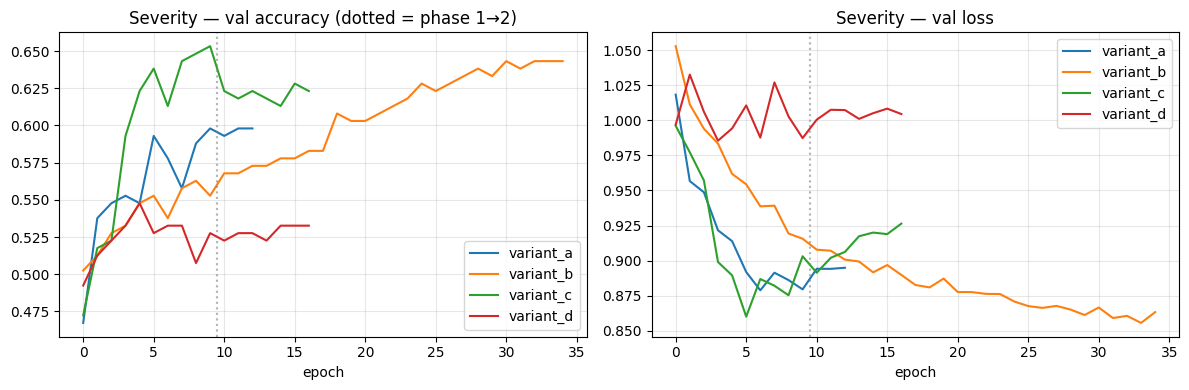

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ['stage3_variant_a', 'stage3_variant_b', 'stage3_variant_c', 'stage3_variant_d']:
    rec = records[name]
    h = rec['history']
    axes[0].plot(h['val_accuracy'], label=name.replace('stage3_', ''))
    axes[1].plot(h['val_loss'],     label=name.replace('stage3_', ''))
    if rec.get('phase2_epochs', 0) > 0:
        boundary = rec['phase1_epochs'] - 0.5
        axes[0].axvline(boundary, ls=':', alpha=0.25, color='gray')
        axes[1].axvline(boundary, ls=':', alpha=0.25, color='gray')
axes[0].set_title('Severity — val accuracy (dotted = phase 1→2)')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Severity — val loss')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()